In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'C'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'C',
 'contract_multiplier': 10,
 'price_tick': 1,
 'margin_rate': 0.07,
 'fee': 0.0,
 'fee_way': 'number',
 'fee_comment': '平今',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-23:00'],
 'light': 1,
 'night': 1,
 'exchange': 'dce',
 'name': '玉米'}

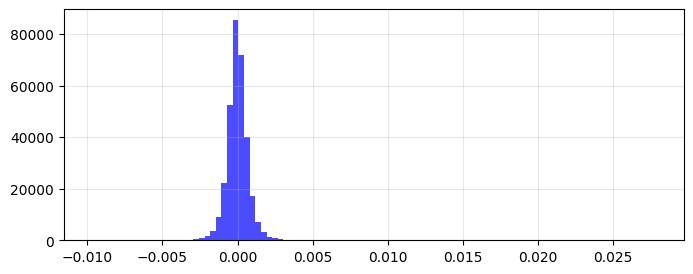

2025-07-01_C_5


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_C|_CS|_RR|_JD|_LH|_AP|_CJ|_SR|_CF|_CY|C_|CS_|RR_|JD_|LH_|AP_|CJ_|SR_|CF_|CY_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['FAC_Depth_Reversal_upmean', 'pred_ret']
特征分布性过滤：
筛选之前因子数量：1881， 筛选之后因子数量：1776

特征重要性过滤： 300 200 	待筛因子个数 1776
无向因子有效个数： 876 有向因子有效个数： 944
  选择有向特征 190 个，重要性范围: 3601.00 - 140.00
  选择无向特征 142 个，重要性范围: 3236.00 - 238.00

单因子sharpe过滤： 0.5 sp范围-16.9057 ~ 1.2738103345051544e+16   待筛因子个数 332

特征相关性性过滤： 300     待筛因子个数 297
  选择特征 238 个, 特征最大相关性0.898822142028045

已挑选日频开盘因子数量： 5 ['day_jump', 'day_first3power', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_jump', 'day_first3power', 'day_first4greencorr', 'day_first10rev', 'day_first10colarrate']

排除指定因子后，剩余特征 238 个


(156, 0, 54, 28)

正在从 /mnt/Data/writable/liaoyuyang/factor/C/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (318166, 1885)
训练集时间范围: 2021-02-02 09:11:00 至 2025-06-30 22:49:00
[200]	valid_0's rmse: 0.995965
[400]	valid_0's rmse: 0.995962
[600]	valid_0's rmse: 0.995957
[800]	valid_0's rmse: 0.995989
[1000]	valid_0's rmse: 0.996029


<Figure size 1000x600 with 0 Axes>

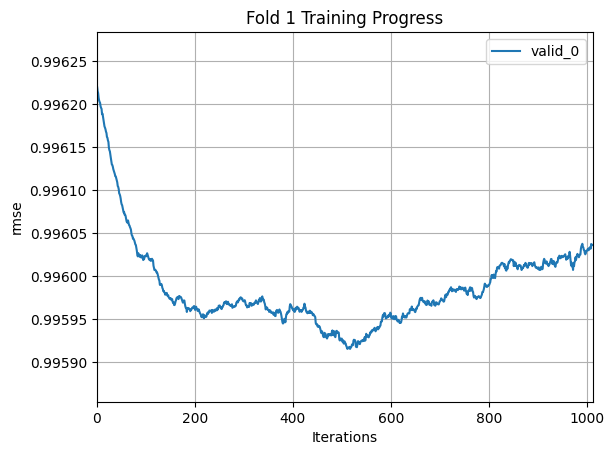

{'train_rmse': np.float64(0.9936708743703354), 'val_rmse': np.float64(0.9996932454790165), 'best_iteration': 512}
test_corr: 0.0566
[200]	valid_0's rmse: 0.995425
[400]	valid_0's rmse: 0.994998
[600]	valid_0's rmse: 0.994738
[800]	valid_0's rmse: 0.99457
[1000]	valid_0's rmse: 0.994436
[1200]	valid_0's rmse: 0.994363
[1400]	valid_0's rmse: 0.994309
[1600]	valid_0's rmse: 0.994291
[1800]	valid_0's rmse: 0.99436
[2000]	valid_0's rmse: 0.994403


<Figure size 1000x600 with 0 Axes>

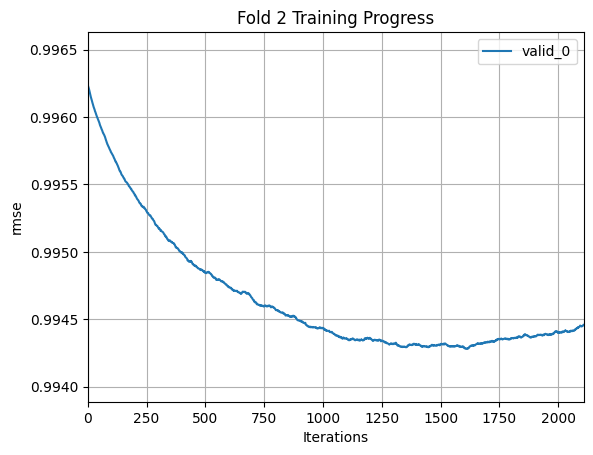

{'train_rmse': np.float64(0.9837709321641566), 'val_rmse': np.float64(0.9980333147578523), 'best_iteration': 1609}
test_corr: 0.0578
[200]	valid_0's rmse: 0.995382
[400]	valid_0's rmse: 0.994935
[600]	valid_0's rmse: 0.99464
[800]	valid_0's rmse: 0.994437
[1000]	valid_0's rmse: 0.994316
[1200]	valid_0's rmse: 0.994193
[1400]	valid_0's rmse: 0.994094
[1600]	valid_0's rmse: 0.994017
[1800]	valid_0's rmse: 0.993929
[2000]	valid_0's rmse: 0.993906
[2200]	valid_0's rmse: 0.993906
[2400]	valid_0's rmse: 0.99389
[2600]	valid_0's rmse: 0.993872
[2800]	valid_0's rmse: 0.993864
[3000]	valid_0's rmse: 0.993873
[3200]	valid_0's rmse: 0.993859


<Figure size 1000x600 with 0 Axes>

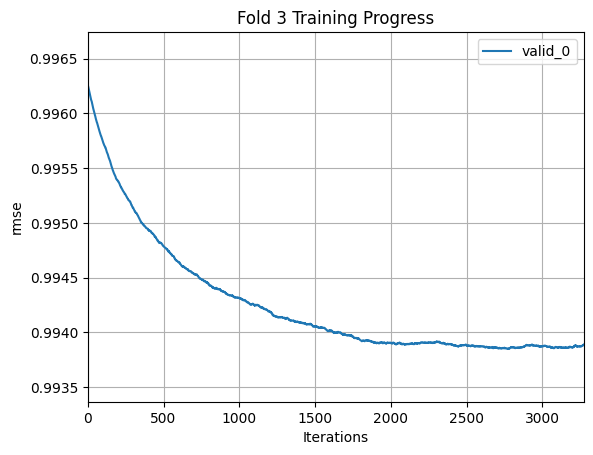

{'train_rmse': np.float64(0.9737738443446609), 'val_rmse': np.float64(0.9975329691079429), 'best_iteration': 2774}
test_corr: 0.0547
[200]	valid_0's rmse: 0.995187
[400]	valid_0's rmse: 0.994651
[600]	valid_0's rmse: 0.994349
[800]	valid_0's rmse: 0.99412
[1000]	valid_0's rmse: 0.993982
[1200]	valid_0's rmse: 0.993849
[1400]	valid_0's rmse: 0.993751
[1600]	valid_0's rmse: 0.993669
[1800]	valid_0's rmse: 0.993659
[2000]	valid_0's rmse: 0.99363
[2200]	valid_0's rmse: 0.993605
[2400]	valid_0's rmse: 0.993592
[2600]	valid_0's rmse: 0.993597
[2800]	valid_0's rmse: 0.993577
[3000]	valid_0's rmse: 0.99357
[3200]	valid_0's rmse: 0.993591
[3400]	valid_0's rmse: 0.993612


<Figure size 1000x600 with 0 Axes>

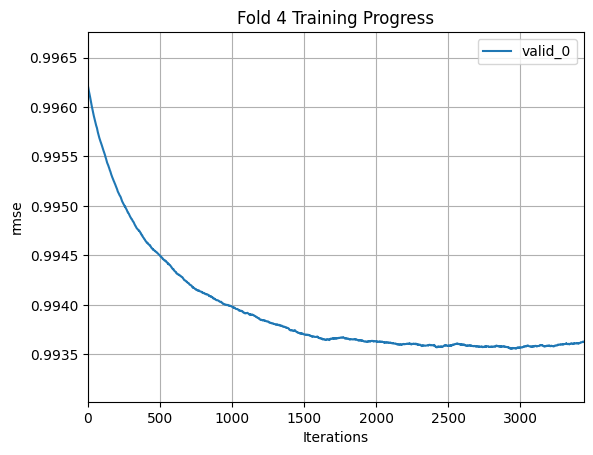

{'train_rmse': np.float64(0.9734346452459675), 'val_rmse': np.float64(0.9971659671109586), 'best_iteration': 2939}
test_corr: 0.0545
[200]	valid_0's rmse: 0.995225
[400]	valid_0's rmse: 0.994795
[600]	valid_0's rmse: 0.994533
[800]	valid_0's rmse: 0.994456
[1000]	valid_0's rmse: 0.994454
[1200]	valid_0's rmse: 0.994458
[1400]	valid_0's rmse: 0.994453


<Figure size 1000x600 with 0 Axes>

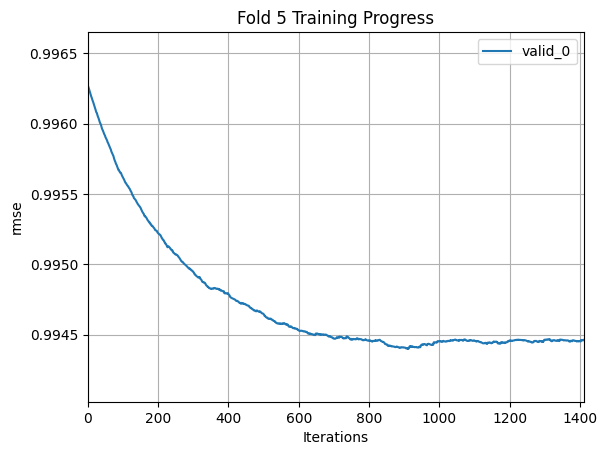

{'train_rmse': np.float64(0.9900441794219914), 'val_rmse': np.float64(0.9981693529310182), 'best_iteration': 911}
test_corr: 0.0644


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/C_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 2_000_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [9]:
bt.mkt_data

,datetime,instrument,open,high,low,close,last_twap,mid_price,volume,turnover,...,spread,bar_count,trade_date,tick10avg,tick0t10avg,tick6t15avg,tick6t60avg,rtn_1,rtn_5,rtn_10
0,2021-02-02 09:01:00,c2105,2769.0,2769.0,2764.0,2765.0,2765.118919,2765.174278,2554.0,70624680.0,...,1.043243,236,2021-02-02,2765.50,2765.406250,2765.193548,2765.065476,0.000606,-0.000171,0.000758
1,2021-02-02 09:02:00,c2105,2765.0,2766.0,2761.0,2763.0,2763.034091,2763.131724,2984.0,82447370.0,...,1.011364,237,2021-02-02,2764.35,2763.896552,2763.384615,2762.905660,0.000070,0.000264,0.000596
2,2021-02-02 09:03:00,c2105,2762.0,2766.0,2762.0,2765.0,2764.425150,2764.454992,1364.0,37707240.0,...,1.000000,229,2021-02-02,2763.10,2763.666667,2764.645161,2764.580000,-0.000454,0.000481,0.000957
3,2021-02-02 09:04:00,c2105,2765.0,2766.0,2764.0,2764.0,2764.784810,2764.880981,503.0,13907410.0,...,1.000000,209,2021-02-02,2764.95,2764.933333,2765.107143,2764.773050,-0.000583,0.001177,0.000807
4,2021-02-02 09:05:00,c2105,2765.0,2765.0,2762.0,2764.0,2763.623529,2763.781502,2123.0,58671950.0,...,1.000000,229,2021-02-02,2764.55,2764.470588,2764.100000,2763.516556,0.000191,0.001291,0.001576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418791,2026-03-09 14:56:00,c2605,2397.0,2398.0,2396.0,2397.0,2397.093220,2397.229330,2342.0,56140400.0,...,1.000000,236,2026-03-09,2397.15,2397.209302,2397.461538,2397.098592,-0.000088,-0.002200,-0.001650
418792,2026-03-09 14:57:00,c2605,2397.0,2397.0,2395.0,2396.0,2395.686192,2396.091778,4254.0,101913430.0,...,1.004184,239,2026-03-09,2396.30,2396.272727,2396.225000,2395.623256,0.000046,-0.002068,-0.001368
418793,2026-03-09 14:58:00,c2605,2396.0,2396.0,2395.0,2396.0,2395.416667,2395.633624,3824.0,91607120.0,...,1.000000,240,2026-03-09,2395.45,2395.454545,2395.475000,2395.412037,-0.000059,-0.001481,-0.001201
418794,2026-03-09 14:59:00,c2605,2396.0,2396.0,2395.0,2395.0,2395.489451,2395.635064,3608.0,86426390.0,...,1.000000,237,2026-03-09,2395.25,2395.318182,2395.525000,2395.521127,-0.001751,-0.001221,-0.001228


In [10]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*345, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


  0%|          | 0/50804 [00:00<?, ?it/s]

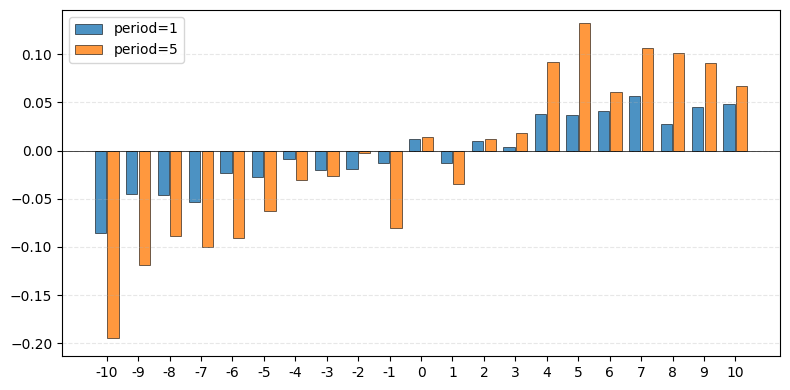

In [11]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-01:00"], g=21)

In [12]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,10691
空头(-1) 数量,10142
空仓(0) 数量,29973
多头占比,21.04%
空头占比,19.96%
空仓占比,59.00%
交易日数量,149
总收益(非年化%),3.97
总交易次数（开平算一次）,2876
日均交易次数（开平算一次）,19.30


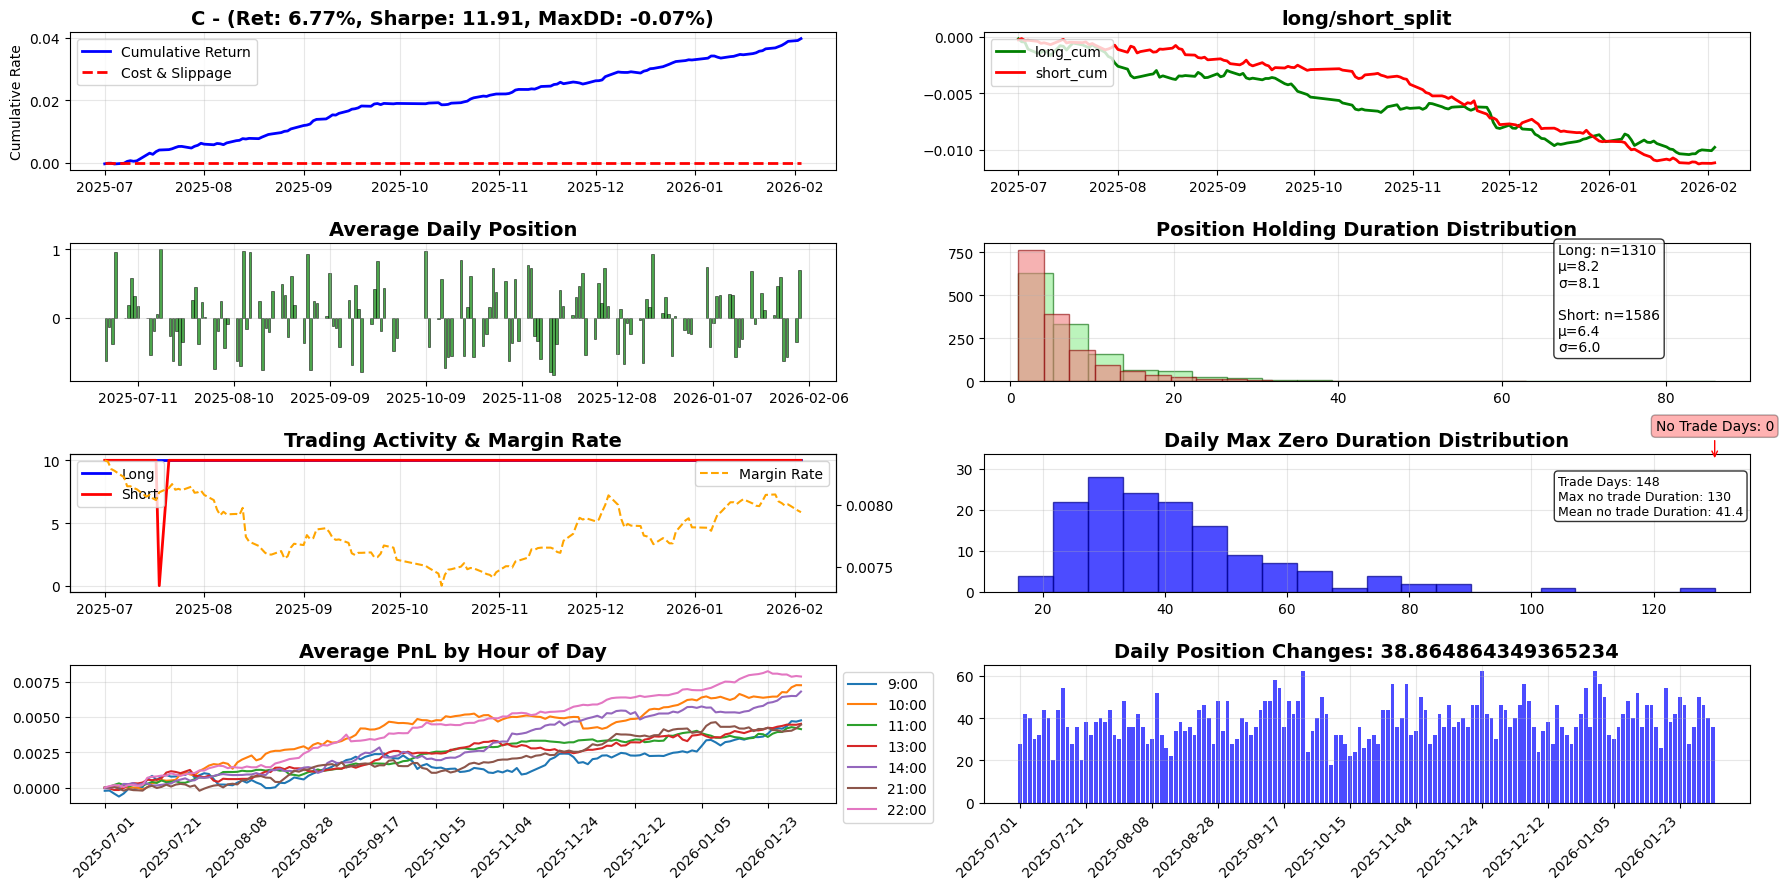

In [13]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [14]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: C
📅 总交易日数: 148
📊 总数据点: 53724
🎯 使用导航按钮或输入页码进行浏览


In [15]:
bv.plot_yearly_eval(merged_data)